<a href="https://colab.research.google.com/github/Chintan0607/LangGraph/blob/main/parallel_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from langgraph.graph import START , END ,StateGraph
from typing import TypedDict

In [25]:
class Batsman(TypedDict):
  runs : int
  balls : int
  fours : int
  sixes : int

  sr:float
  bpb:float
  boundary_percent :float
  summary :str

In [26]:
def calculate_sr(state:Batsman):
  sr = (state['runs']/state['balls'])/100
  # state['sr'] =sr
  return {'sr':sr}

In [27]:
def calculate_bpb(state:Batsman):
  bpb = state['balls']/(state['fours']+state['sixes'])
  state['bpb']=bpb
  return {'bpb':bpb}


In [28]:
def calculate_boundary_percent(state:Batsman):
  boundary_percent = (((state['fours']*4)+(state['sixes']*6))/state['runs'])*100
  return {'boundary_percent':boundary_percent}

In [29]:
def summary(state:Batsman):
  summary =f"""
  Strike Rate - {state['sr']}\n
  Balls per boundary -{state['bpb']}\n
  Boundary percent - {state['boundary_percent']}
  """
  state['summary'] =summary
  return state

In [30]:
from sys import get_coroutine_origin_tracking_depth
graph =StateGraph(Batsman)
graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
graph.add_node("calculate_bondary_percent",calculate_boundary_percent)
graph.add_node("summary",summary)
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge(START,'calculate_bondary_percent')
graph.add_edge("calculate_sr",'summary')
graph.add_edge("calculate_bpb",'summary')
graph.add_edge('calculate_bondary_percent','summary')
graph.add_edge('summary',END)
workflow= graph.compile()

In [31]:
initial_state = {'runs' : 100,
  'balls' : 50 ,
  'fours' : 6 ,
  'sixes' : 4}

In [32]:
workflow.invoke(initial_state)

{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 0.02,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\n  Strike Rate - 0.02\n\n  Balls per boundary -5.0\n\n  Boundary percent - 48.0\n  '}

In [33]:
from IPython.display import Image,display

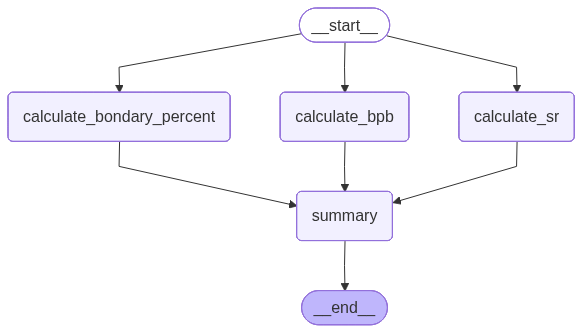

In [34]:
display(Image(workflow.get_graph().draw_mermaid_png()))